Libraries loaded!
RFM Shape: (5878, 10)

Columns: ['customer_id', 'recency', 'frequency', 'monetary', 'monetary_log', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment']

First 5 rows:
  customer_id  recency  frequency  monetary  monetary_log  r_score  f_score  \
0       12346      326         12  77556.46     11.258774        2        5   
1       12347        2          8   5633.32      8.636632        5        4   
2       12348       75          5   2019.40      7.611051        3        4   
3       12349       19          4   4428.69      8.396085        5        3   
4       12350      310          1    334.40      5.815324        2        1   

   m_score  rfm_score          segment  
0        5         12          At Risk  
1        5         14        Champions  
2        4         11  Loyal Customers  
3        5         13  Loyal Customers  
4        2          5             Lost  
Total Customers : 5,878
Churned : 2,989
Active : 2,889
Churn Rate : 50.9%
Features shape:

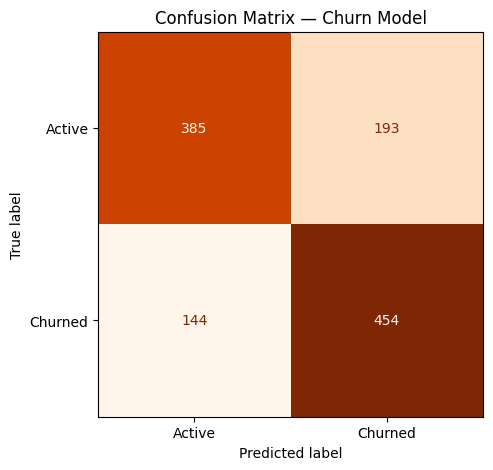

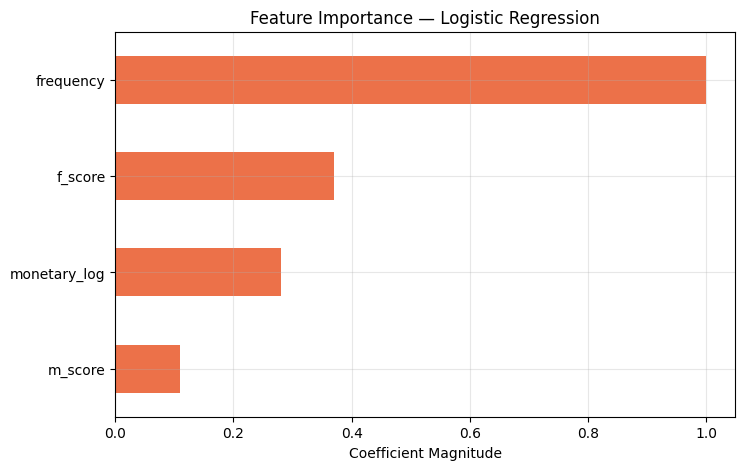

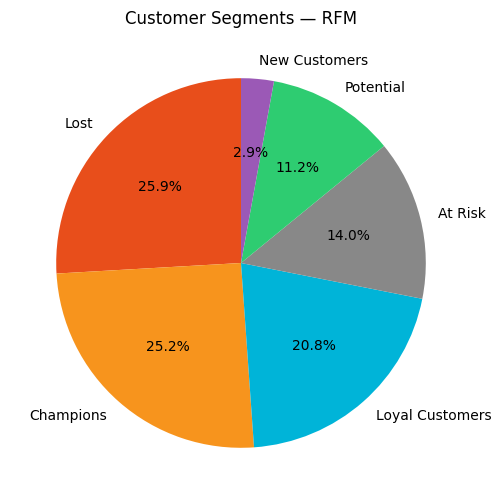

2026/04/18 16:06:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:06:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'ChurnModel_Baseline' already exists. Creating a new version of this model...
2026/04/18 16:06:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ChurnModel_Baseline, version 2



Model registered in MLflow!
Run complete — AUC: 0.7765
🏃 View run LogReg_Baseline at: http://localhost:5000/#/experiments/2/runs/06df4cb82ffb45ab9ccbe6eaecbe6d55
🧪 View experiment at: http://localhost:5000/#/experiments/2


Created version '2' of model 'ChurnModel_Baseline'.


In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, 
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded!')

# Cell 2: MLflow setup
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('NeuralRetail_Churn_Prediction')

# Cell 3: Data load karo
rfm = pd.read_parquet(r'../data/features/rfm_features.parquet')

print('RFM Shape:', rfm.shape)
print('\nColumns:', rfm.columns.tolist())
print('\nFirst 5 rows:')
print(rfm.head())

# Cell 4: Churn label banao
# 90+ din se inactive = churned
rfm['churned'] = (rfm['recency'] > 90).astype(int)

churn_rate = rfm['churned'].mean() * 100
print(f'Total Customers : {len(rfm):,}')
print(f'Churned : {rfm["churned"].sum():,}')
print(f'Active : {(rfm["churned"]==0).sum():,}')
print(f'Churn Rate : {churn_rate:.1f}%')

# Cell 5: Features aur target
feature_cols = [
    'frequency', 
    'monetary_log',
    'f_score', 
    'm_score'
]

X = rfm[feature_cols].astype(float)
y = rfm['churned']

print('Features shape:', X.shape)
print('Null check:\n', X.isnull().sum())

# Cell 6: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # class balance maintain karo
)

print(f'Train size : {len(X_train):,}')
print(f'Test size : {len(X_test):,}')

# Cell 7: MLflow run
mlflow.end_run()

with mlflow.start_run(run_name='LogReg_Baseline'):

    # Scale karo
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Model train karo
    lr = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced' # imbalanced data handle karo
    )
    lr.fit(X_train_s, y_train)

    # Predictions
    y_pred_proba = lr.predict_proba(X_test_s)[:, 1]
    y_pred = lr.predict(X_test_s)

    # Metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    accuracy = (y_pred == y_test).mean() * 100

    # MLflow log
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_param('test_size', 0.2)
    mlflow.log_metric('AUC_ROC', round(auc, 4))
    mlflow.log_metric('Accuracy', round(accuracy, 2))

    # Classification report print karo
    print('=' * 45)
    print(' Churn Model — Baseline Results')
    print('=' * 45)
    print(f' AUC-ROC : {auc:.4f} (Target: >= 0.75)')
    print(f' Accuracy : {accuracy:.1f}%')
    print('=' * 45)
    print('\nClassification Report:')
    print(classification_report(
        y_test, y_pred,
        target_names=['Active', 'Churned']
    ))

    # Plot 1: Confusion Matrix
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Active', 'Churned']
    )
    disp.plot(ax=ax1, colorbar=False, cmap='Oranges')
    ax1.set_title('Confusion Matrix — Churn Model')
    fig1.savefig(r'../reports/churn_confusion_matrix.png', 
                 dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/churn_confusion_matrix.png')
    plt.show()

    # Plot 2: Feature Importance
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    importance = pd.Series(
        np.abs(lr.coef_[0]),
        index=feature_cols
    ).sort_values(ascending=True)

    importance.plot(
        kind='barh',
        ax=ax2,
        color='#E84E1B',
        alpha=0.8
    )
    ax2.set_title('Feature Importance — Logistic Regression')
    ax2.set_xlabel('Coefficient Magnitude')
    ax2.grid(True, alpha=0.3)
    fig2.savefig(r'../reports/churn_feature_importance.png',
                 dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/churn_feature_importance.png')
    plt.show()

    # Plot 3: Churn segments pie chart
    fig3, ax3 = plt.subplots(figsize=(6, 6))
    segment_counts = rfm['segment'].value_counts()
    colors = ['#E84E1B','#F7941D','#00B4D8',
              '#888888','#2ECC71','#9B59B6']
    ax3.pie(
        segment_counts.values,
        labels=segment_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90
    )
    ax3.set_title('Customer Segments — RFM')
    fig3.savefig(r'../reports/customer_segments.png',
                 dpi=150, bbox_inches='tight')
    mlflow.log_artifact(r'../reports/customer_segments.png')
    plt.show()

    # Model register karo
    mlflow.sklearn.log_model(
        lr,
        artifact_path='logistic_regression_model',
        registered_model_name='ChurnModel_Baseline'
    )
    print('\nModel registered in MLflow!')
    print(f'Run complete — AUC: {auc:.4f}')